In [1]:
import pandas as pd
import seaborn as sns
from google.colab import drive
import plotly.express as px
import matplotlib.pyplot as plt


## Poverty statistics

The data comes from the [SDG Tracker](https://sdg-tracker.org/no-poverty) website, which belongs to [Our World in Data](https://ourworldindata.org/).
[SDG Tracker](https://sdg-tracker.org/no-poverty) initiative was created to publish information on United Nations' Sustainable Development Goals (SDGs).
These are the global development goals adopted by the UN in September 2015, which should be achieved by 2030

### Dataset contents

This dataset collects the information on:
*   the name of the country - **Country**,
*   a three-character country code - **Code**,
*   the continent where the country is - **Continent**,
*   the year the statistics are for - **Year**,
*   share of the population that lives in extreme poverty- **Share Extreme Poverty**,
*   indicator of the population living below the international poverty line - **Poverty Headcount Ratio**,
*   multidimensional poverty index - **Share Multipoverty**,
*   share of the population covered by social insurance - **SIP Coverage**,
*   number of deaths, missing persons, and direct victims of natural disasters per 100 000 of population - **Disasters Deaths and Missings**,
*   number of persons who remained in the country after losing shelter as a result of natural disasters - **Disasters Internally Displaced**,
*   number of persons directly affected by the results of natural disasters per 100 000 of population - **Disasters Directly Affected**,
*   financial losses caused by natural disasters, given as a percentage of GDP - **Disasters Direct Economic Loss**,
*   share of healthcare expenditure in the total government expenditure - **Gov Expenditure Health**,
*   share of education expenditure in the total government expenditure - **Gov Expenditure Education**.

The data has been adapted to combine the information for specific countries and years and add continent information.

The necessary data is provided with the document: the code below imports the file.

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
poverty_data = pd.read_csv('/content/drive/My Drive/Vis/Poverty Data/poverty_statistics.csv')
poverty_data

,Country,Code,Continent,Year,SIP Coverage,Disasters Deaths and Missings,Disasters Direct Economic Loss,Gov Expenditure Education,Gov Expenditure Health,Disasters Internally Displaced,Disasters Directly Affected,Share Multipoverty,Share Extreme Poverty,Poverty Headcount Ratio
0,Afghanistan,AFG,Asia,2007,0.539037,NaN,NaN,NaN,2.949193,NaN,NaN,NaN,NaN,36.3
1,Afghanistan,AFG,Asia,2011,NaN,NaN,NaN,16.048429,10.174108,3000.0,NaN,66.2,NaN,35.8
2,Albania,ALB,Europe,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.464528,NaN
3,Albania,ALB,Europe,2002,NaN,NaN,NaN,9.886920,7.192037,NaN,NaN,NaN,1.570843,25.4
4,Albania,ALB,Europe,1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.407918,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7295,French Polynesia,PYF,Oceania,2007,NaN,7.61275,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7296,Kuwait,KWT,Asia,2020,NaN,19.44029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7297,Lebanon,LBN,Asia,2020,NaN,0.01465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7298,New Caledonia,NCL,Oceania,2009,NaN,1.59948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Notebook preparation

We need to start by making sure that the data has been correctly identified and make necessary conversions.

Looking at the data overview above, we can expect that the continent information is going to be interesting categorical data.

In the case of individual countries, we expect a great variety in data.

For numeric data, we need to identify how often information is missing; it is also a good idea to know the basic statistical information.

### Checking data types

In [4]:
poverty_data.dtypes

,0
Country,object
Code,object
Continent,object
Year,int64
SIP Coverage,float64
Disasters Deaths and Missings,float64
Disasters Direct Economic Loss,float64
Gov Expenditure Education,float64
Gov Expenditure Health,float64
Disasters Internally Displaced,float64


In [5]:
"complete records: " + str(len(poverty_data.dropna(how="any"))) + "; total records: " + str(len(poverty_data))

'complete records: 4; total records: 7300'

In [6]:
poverty_data.isnull().sum()

,0
Country,0
Code,0
Continent,0
Year,0
SIP Coverage,6903
Disasters Deaths and Missings,5961
Disasters Direct Economic Loss,6124
Gov Expenditure Education,4534
Gov Expenditure Health,3550
Disasters Internally Displaced,5949


Because of how the data has been combined, all records include the information on the country, code, continent, and year.
For other statistics, we have the most data in the **Share Extreme Poverty** column.
Majority of the records have no information in the **Share Multipoverty** and **SIP Coverage** columns.

Second are **Poverty Headcount Ratio** and **Disasters Direct Economic Loss**.

We can assume that for these four columns researching the relations between features may be problematic: considering this, we'll try to identify a set of records where it's justified.

### Identifying countries in the set

Let's consider how many, and what countries are in the set.

In [7]:
poverty_data["Country"].value_counts()

,count
Country,
Bangladesh,41
Ethiopia,41
Ghana,41
Sweden,41
Angola,40
...,...
British Virgin Islands,1
Cayman Islands,1
Saint Martin (French part),1


We have statistics for 213 countries, and the data is varied between them. We have some countries with certain data for 41 years, and other ones with data for only one year.

### Converting continent names to categories

We can be sure that the number of continents is not very high.

In [8]:
poverty_data["Continent"].value_counts()

,count
Continent,
Africa,2045
Asia,1772
Europe,1675
North America,839
Oceania,506
South America,463


In [9]:
poverty_data["Continent"] = poverty_data["Continent"].astype("category")

## Preparing dataframes

#### Analyzing social programs and government expenditure ratio

Let's pick a single year where we can see only a low number of missing information for the columns we're interested in.

In [10]:
years_and_nulls = pd.DataFrame(pd.Series(poverty_data["Year"].unique(), name="unique year"))
years_and_nulls["nulls"] = years_and_nulls["unique year"].apply(lambda x: poverty_data[(poverty_data["Year"]==x)].isnull().sum().sum())
years_and_nulls["records"] = years_and_nulls["unique year"].apply(lambda x: len(poverty_data[(poverty_data["Year"]==x)]))
years_and_nulls["nulls per record"] = years_and_nulls["nulls"]/years_and_nulls["records"]
years_and_nulls.sort_values(by="unique year")
years_and_nulls[years_and_nulls["nulls per record"]==years_and_nulls["nulls per record"].min()]

,unique year,nulls,records,nulls per record
8,2012,1048,198,5.292929


Data for 2012 looks promising.

In [11]:
poverty_data_one_year =  poverty_data[poverty_data["Year"]==2012]
poverty_data_one_year

,Country,Code,Continent,Year,SIP Coverage,Disasters Deaths and Missings,Disasters Direct Economic Loss,Gov Expenditure Education,Gov Expenditure Health,Disasters Internally Displaced,Disasters Directly Affected,Share Multipoverty,Share Extreme Poverty,Poverty Headcount Ratio
8,Albania,ALB,Europe,2012,36.255063,0.27582,0.000924,NaN,9.710531,NaN,59.29575,NaN,0.849754,14.3
49,Algeria,DZA,Africa,2012,NaN,0.11468,0.000165,NaN,9.988192,NaN,11.91092,NaN,0.415515,NaN
87,Angola,AGO,Africa,2012,NaN,0.38759,0.000198,NaN,5.573031,6400.0,106.66125,NaN,36.781340,NaN
124,Argentina,ARG,South America,2012,28.969560,0.16773,0.003772,14.518260,8.741289,2000.0,542.71734,NaN,NaN,NaN
136,Armenia,ARM,Asia,2012,53.362759,9.06864,0.000009,12.368970,7.438755,NaN,115.01291,NaN,0.916995,32.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7149,Saudi Arabia,SAU,Asia,2012,NaN,NaN,NaN,NaN,7.749074,NaN,NaN,NaN,NaN,NaN
7168,Singapore,SGP,Asia,2012,NaN,NaN,NaN,31.371750,11.098890,NaN,NaN,NaN,NaN,NaN
7187,Aruba,ABW,North America,2012,NaN,NaN,NaN,20.634081,NaN,NaN,NaN,NaN,NaN,NaN
7234,Hong Kong,HKG,Asia,2012,NaN,NaN,NaN,18.649481,NaN,NaN,NaN,NaN,NaN,NaN


In this case we have certain information for 198 countries. Let's consider what information is most often missing.

In [12]:
poverty_data_one_year.isnull().sum()

,0
Country,0
Code,0
Continent,0
Year,0
SIP Coverage,159
Disasters Deaths and Missings,109
Disasters Direct Economic Loss,119
Gov Expenditure Education,89
Gov Expenditure Health,8
Disasters Internally Displaced,119


Next, we select the records on 2012 where we have the information on **SIP Coverage**, **Share Extreme Poverty**, and **Gov Expenditure Education**.

In [13]:
selected = poverty_data[(poverty_data["Year"]==2012)& (poverty_data["Share Extreme Poverty"].isnull()==False) &
                        (poverty_data["SIP Coverage"].isnull()==False) & (poverty_data["Gov Expenditure Education"].isnull()==False)
]
SIP_extreme_poverty = selected[["Country","Continent","SIP Coverage", "Share Extreme Poverty","Gov Expenditure Education"]]
SIP_extreme_poverty

,Country,Continent,SIP Coverage,Share Extreme Poverty,Gov Expenditure Education
136,Armenia,Asia,53.362759,0.916995,12.368970
194,Belarus,Europe,47.925471,0.000000,12.752300
227,Brazil,South America,28.344648,3.731201,15.727670
277,Colombia,South America,8.897965,6.247937,15.512830
287,Costa Rica,North America,15.028445,1.691766,23.501560
356,Ecuador,South America,10.674940,4.494096,11.534150
383,El Salvador,North America,5.477152,4.219873,15.279990
823,Ghana,Africa,59.520414,12.169250,37.520962
980,Guinea,Africa,2.284316,36.093460,9.460610
1040,Kyrgyzstan,Asia,41.640562,2.482169,18.195009


#### Extreme poverty share in Africa and South America

To create a **Share Extreme Poverty** comparison for the two continents we need to use appropriate filtering.

Because the continent is identified as a category, we also need to remove the categories we are not currently interested in.

In [14]:
share_extreme_poverty =  poverty_data[
                                      (poverty_data["Share Extreme Poverty"].isnull()==False)
                                       & ((poverty_data["Continent"]=="Africa")  | (poverty_data["Continent"]=="South America"))
                                      ][["Country",	"Continent", "Year", "Share Extreme Poverty"]]
share_extreme_poverty["Continent"] = share_extreme_poverty["Continent"].cat.remove_unused_categories()
share_extreme_poverty

,Country,Continent,Year,Share Extreme Poverty
41,Algeria,Africa,2011,0.470209
42,Algeria,Africa,2013,0.380704
43,Algeria,Africa,2005,2.032179
44,Algeria,Africa,2006,1.745856
45,Algeria,Africa,2007,1.400125
...,...,...,...,...
6389,Zimbabwe,Africa,2013,22.473590
6390,Zimbabwe,Africa,2014,25.462180
6391,Zimbabwe,Africa,2015,28.671930
6392,Zimbabwe,Africa,2016,32.366640


### Statistics for chosen continents

Similarly to the above case, we choose four continents that we'll need to create visualizations for.

At the same time we make sure that the range of categories to be displayed in the chart is appropriately set.

In [15]:
selected_continents =  poverty_data[(poverty_data["Continent"]=="Africa")
| (poverty_data["Continent"]=="Europe")
| (poverty_data["Continent"]=="Asia")
| (poverty_data["Continent"]=="North America")
                                      ]
selected_continents["Continent"] = selected_continents["Continent"].cat.remove_unused_categories()
selected_continents

/tmp/ipykernel_1854/2828507358.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_continents["Continent"] = selected_continents["Continent"].cat.remove_unused_categories()


,Country,Code,Continent,Year,SIP Coverage,Disasters Deaths and Missings,Disasters Direct Economic Loss,Gov Expenditure Education,Gov Expenditure Health,Disasters Internally Displaced,Disasters Directly Affected,Share Multipoverty,Share Extreme Poverty,Poverty Headcount Ratio
0,Afghanistan,AFG,Asia,2007,0.539037,NaN,NaN,NaN,2.949193,NaN,NaN,NaN,NaN,36.3
1,Afghanistan,AFG,Asia,2011,NaN,NaN,NaN,16.048429,10.174108,3000.0,NaN,66.2,NaN,35.8
2,Albania,ALB,Europe,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.464528,NaN
3,Albania,ALB,Europe,2002,NaN,NaN,NaN,9.886920,7.192037,NaN,NaN,NaN,1.570843,25.4
4,Albania,ALB,Europe,1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.407918,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7290,Turks and Caicos Islands,TCA,North America,2015,NaN,NaN,NaN,14.262220,NaN,NaN,NaN,NaN,NaN,NaN
7291,Turks and Caicos Islands,TCA,North America,2018,NaN,NaN,NaN,12.123300,NaN,NaN,NaN,NaN,NaN,NaN
7294,Equatorial Guinea,GNQ,Africa,2015,NaN,0.32721,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7296,Kuwait,KWT,Asia,2020,NaN,19.44029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


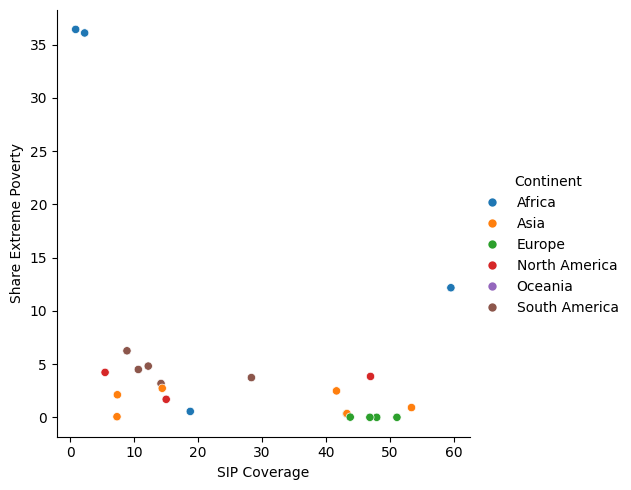

In [16]:
sns.relplot(data=SIP_extreme_poverty,
  x=SIP_extreme_poverty["SIP Coverage"],
  y=SIP_extreme_poverty["Share Extreme Poverty"],
  hue=SIP_extreme_poverty["Continent"]
  );

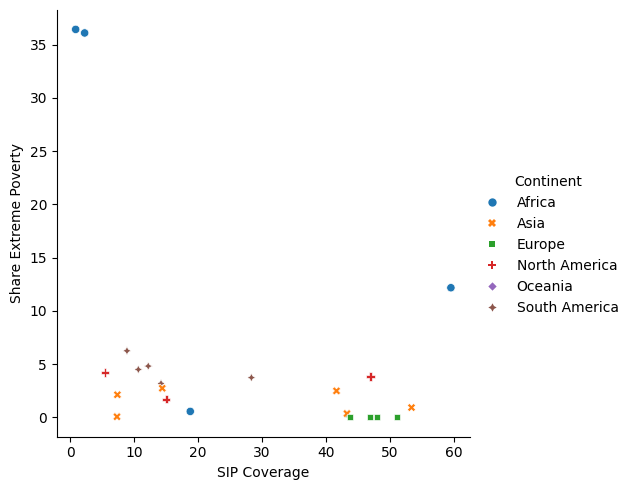

In [17]:
sns.relplot(data=SIP_extreme_poverty,
  x=SIP_extreme_poverty["SIP Coverage"],
  y=SIP_extreme_poverty["Share Extreme Poverty"],
  hue=SIP_extreme_poverty["Continent"],
  style=SIP_extreme_poverty["Continent"]
  );

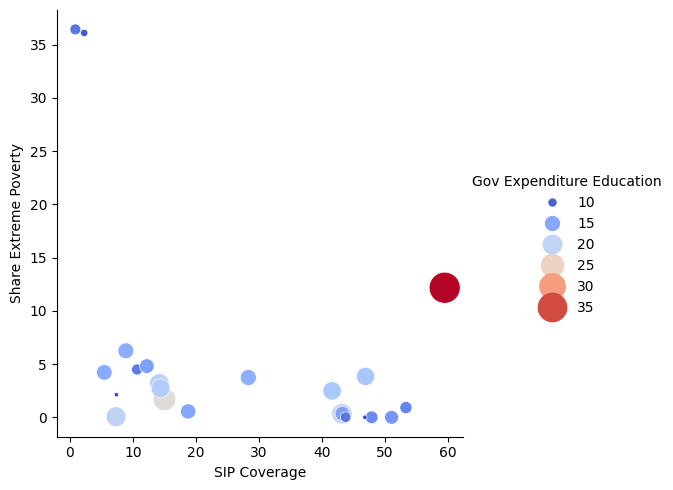

In [18]:
sns.relplot(data=SIP_extreme_poverty,
  x=SIP_extreme_poverty["SIP Coverage"],
  y=SIP_extreme_poverty["Share Extreme Poverty"],
  size=SIP_extreme_poverty["Gov Expenditure Education"],
  sizes=(10,500),
  hue=SIP_extreme_poverty["Gov Expenditure Education"],
  palette="coolwarm"
  );

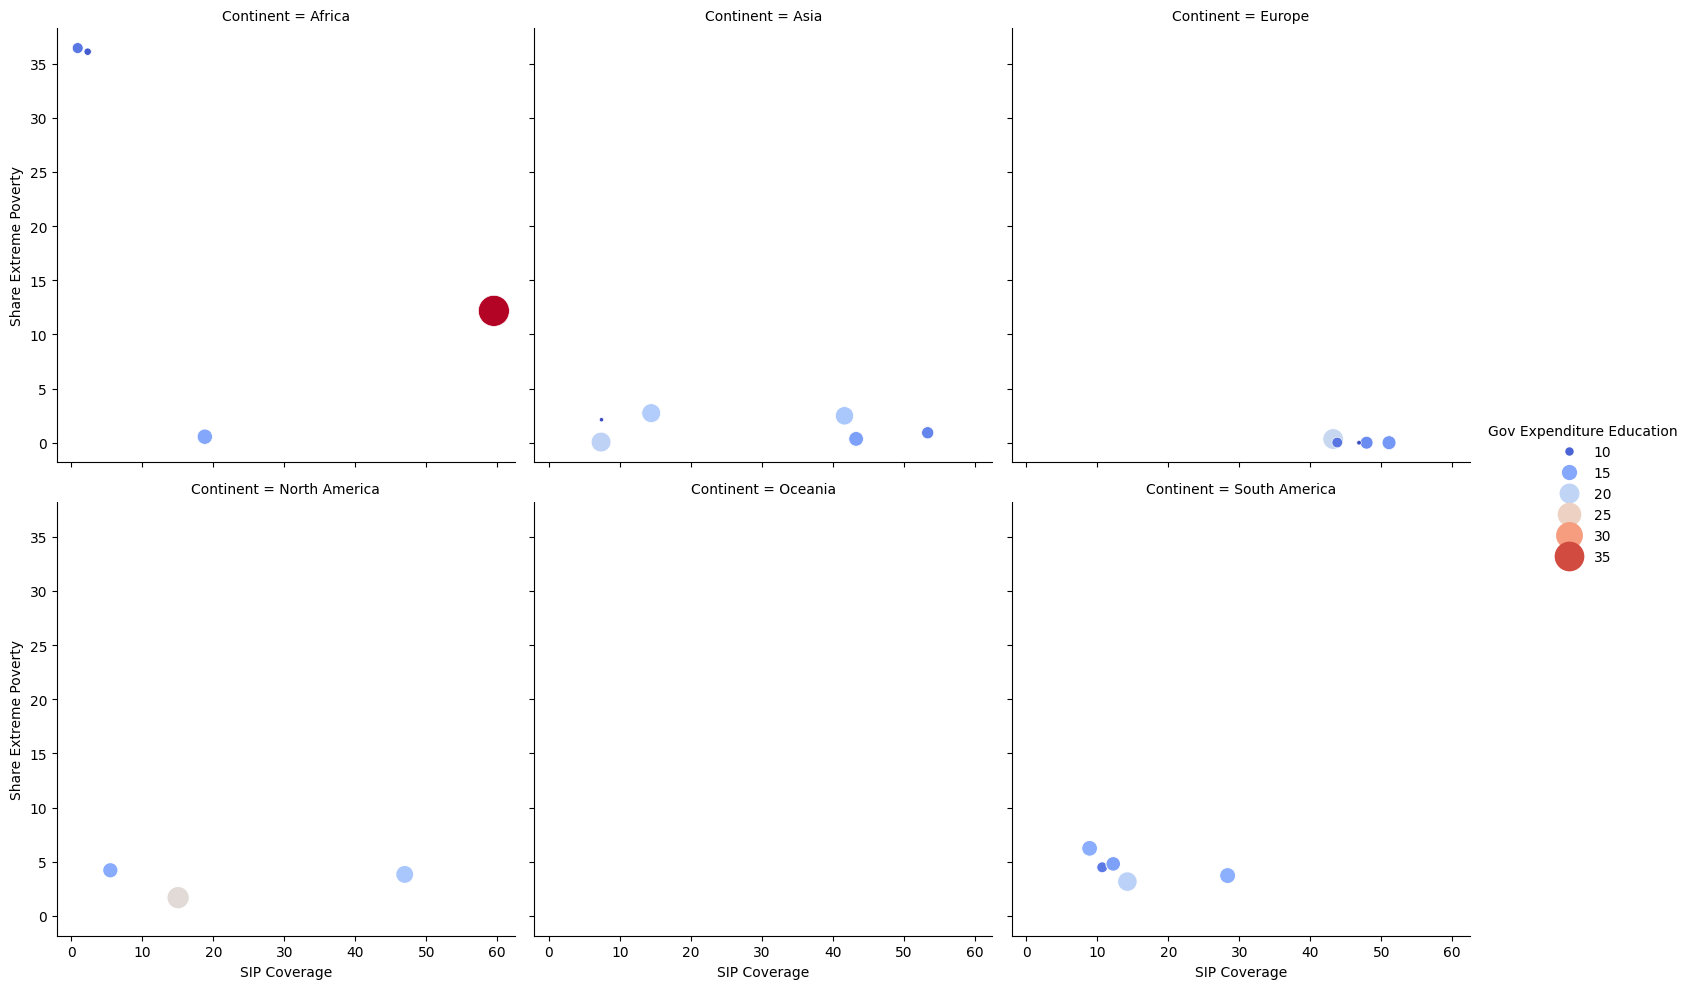

In [19]:
sns.relplot(data=SIP_extreme_poverty,
  x=SIP_extreme_poverty["SIP Coverage"],
  y=SIP_extreme_poverty["Share Extreme Poverty"],
  size=SIP_extreme_poverty["Gov Expenditure Education"],
  sizes=(10,500),
  hue=SIP_extreme_poverty["Gov Expenditure Education"],
  palette="coolwarm",
  col=SIP_extreme_poverty["Continent"],
  col_wrap=3
  );

## Exercises

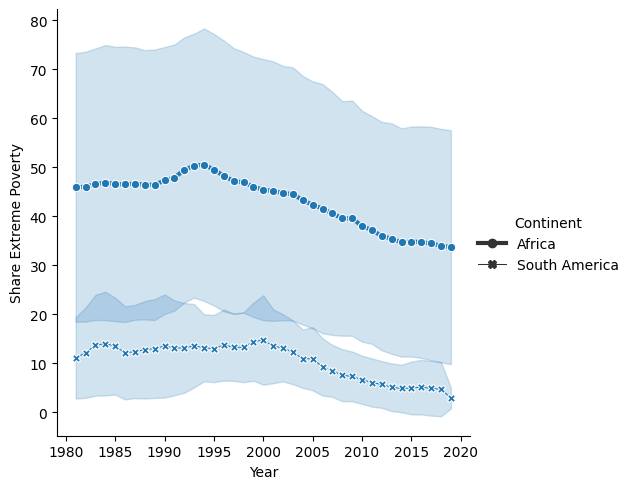

In [20]:
sns.relplot(data=share_extreme_poverty,
  x=share_extreme_poverty["Year"],
  y=share_extreme_poverty["Share Extreme Poverty"],
  kind="line",
  errorbar='sd', #gives a visualization of the standard deviation for each data point on the line plot.-confidence intervals
  style=share_extreme_poverty["Continent"],
  dashes=False,#default True; indicates the type of line
  markers=True,#default False; marker distinguishes the style of line
  size=share_extreme_poverty["Continent"]
  );

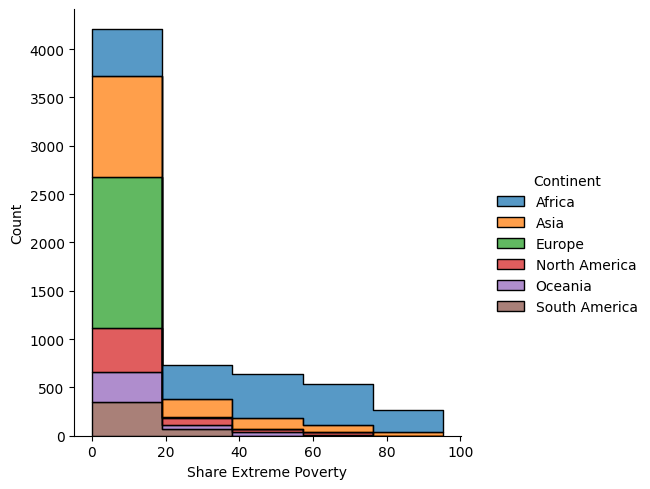

In [21]:
#distributons-what frequency certain groups of values occur for a given variable
sns.displot(data=poverty_data,
  x=poverty_data["Share Extreme Poverty"],
  hue=poverty_data["Continent"],
  bins=10,
  binwidth=20,
  element="step",#choose a step plot type
  multiple="stack",
  );

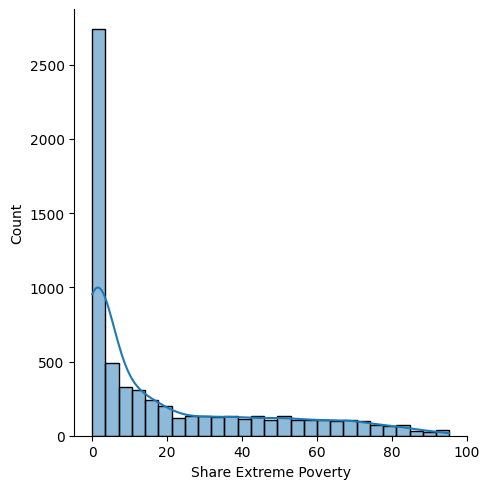

In [22]:
#We can also represent the distribution using a kernel density estimator, which returns a smoothed form of the histogram
#smoothed form may lead to misinterpretation of the data.
sns.displot(data=poverty_data,
  x=poverty_data["Share Extreme Poverty"],
  kde=True
  );

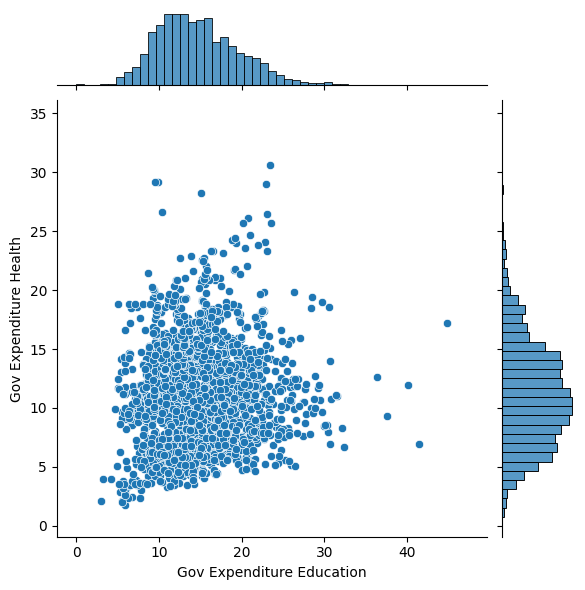

In [23]:
sns.jointplot(data=poverty_data,
  x=poverty_data["Gov Expenditure Education"],
  y=poverty_data["Gov Expenditure Health"]
  );

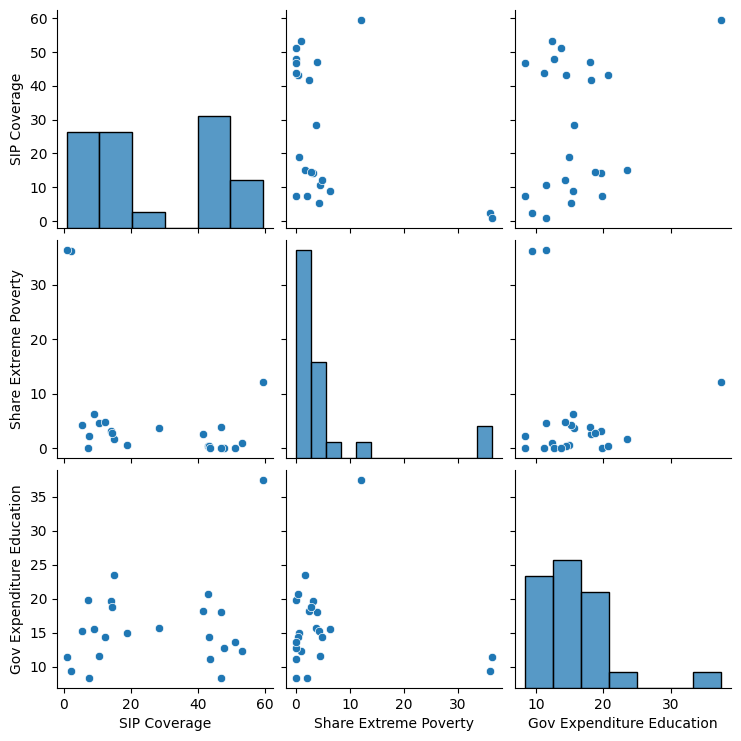

In [24]:
sns.pairplot(data=SIP_extreme_poverty);

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 19.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 27.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 7.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


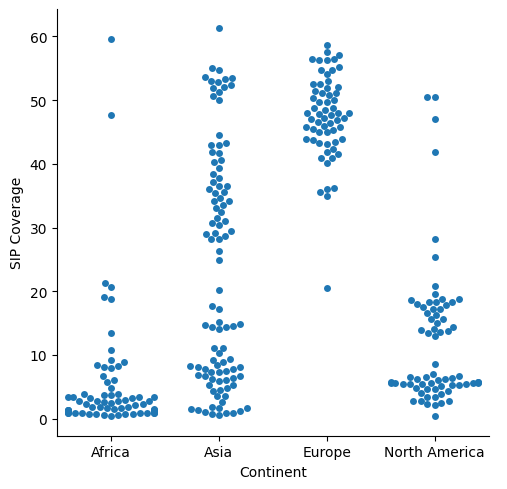

In [25]:
sns.catplot(data=selected_continents,
  x="Continent",
  y="SIP Coverage",
  kind="swarm"
  );

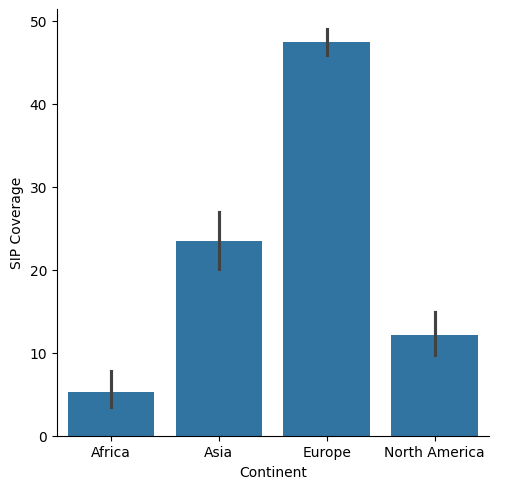

In [26]:
sns.catplot(data=selected_continents,
  x="Continent",
  y="SIP Coverage",
  kind="bar"
  );

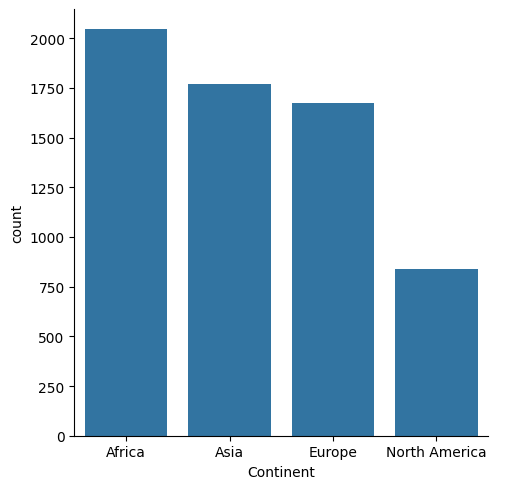

In [27]:
sns.catplot(data=selected_continents,
  x="Continent",
  kind="count"
  );

Generating pairplot for selected numerical features...


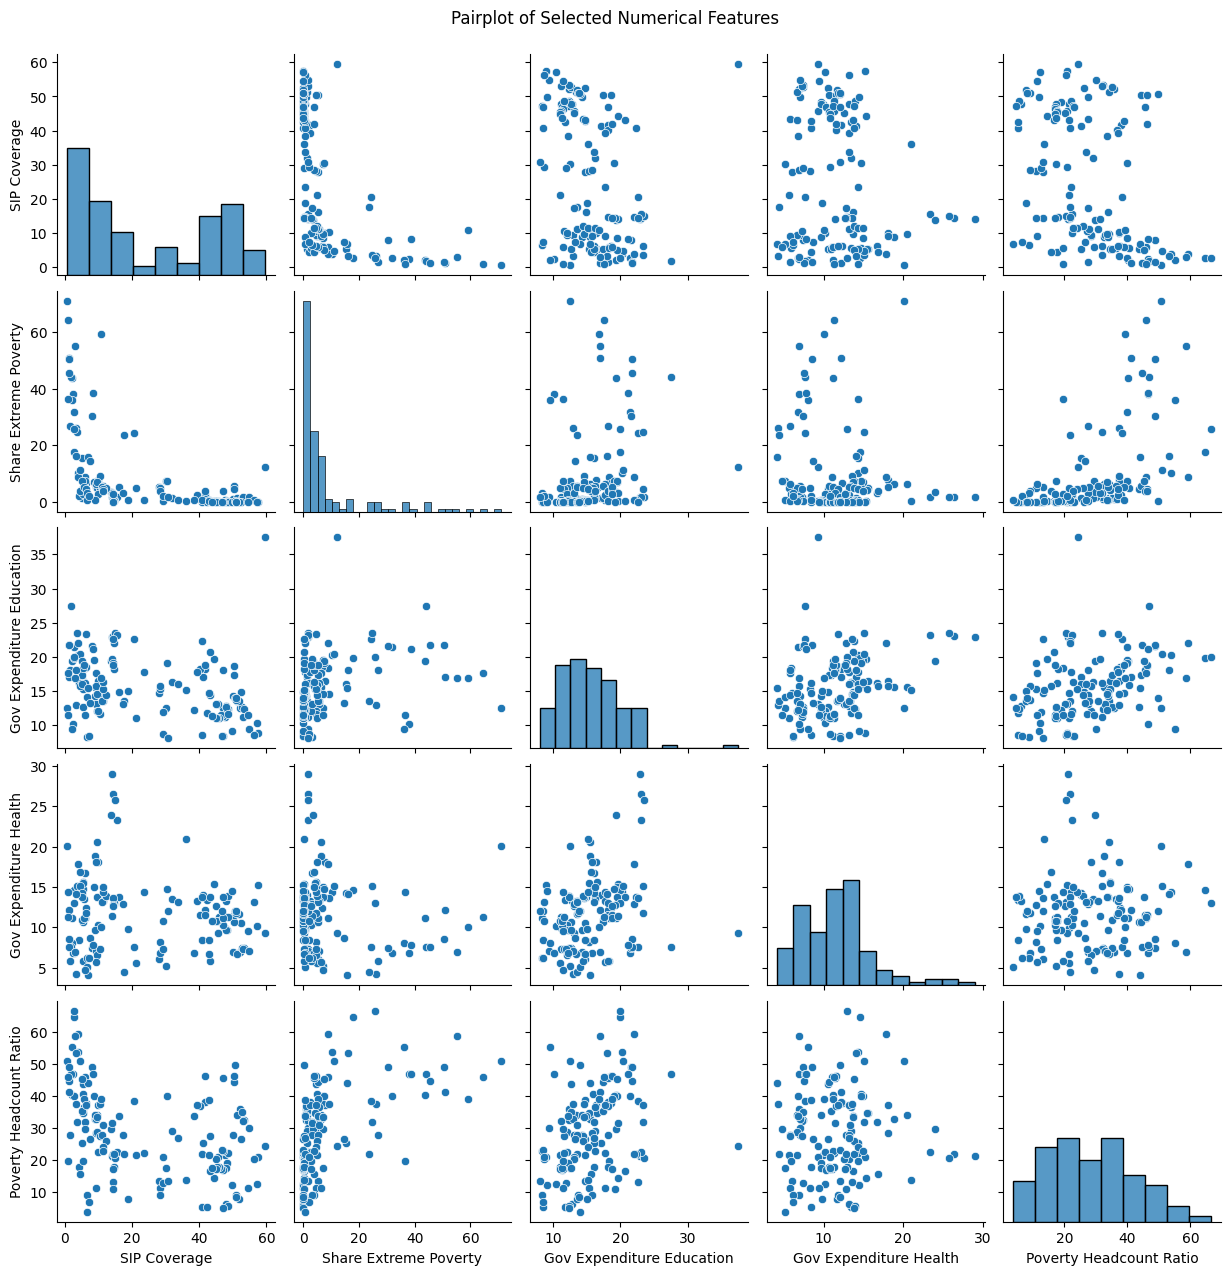


Generating jointplot for SIP Coverage vs Share Extreme Poverty...


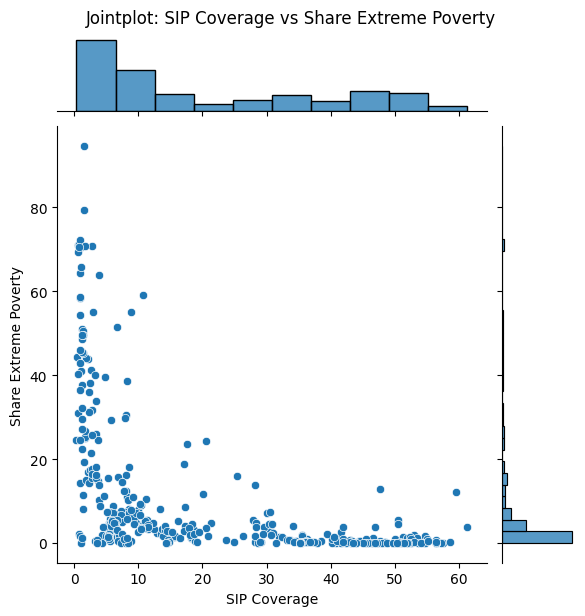


Generating jointplot for Gov Expenditure Education vs Gov Expenditure Health...


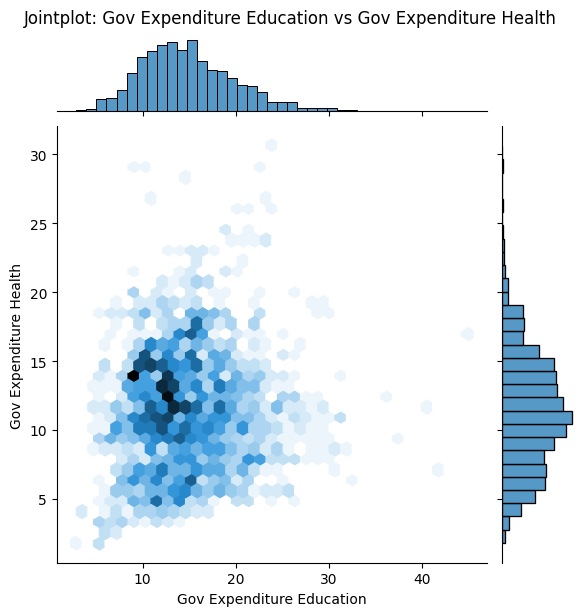


Plotting distributions of all numerical features...


<Figure size 800x400 with 0 Axes>

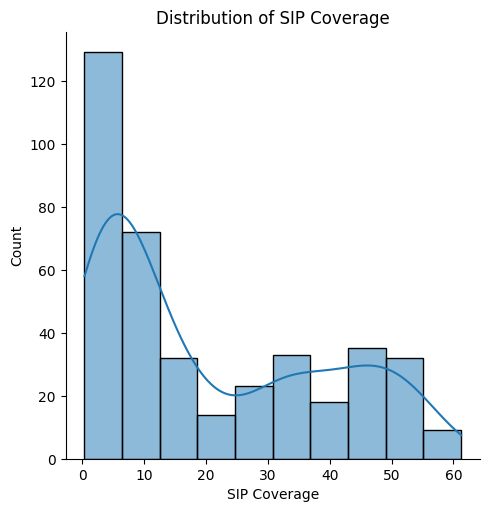

<Figure size 800x400 with 0 Axes>

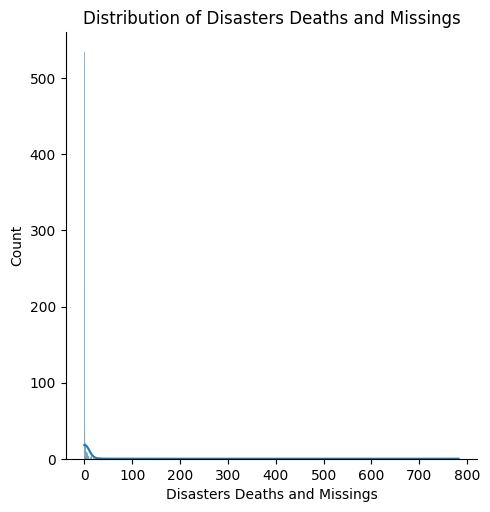

<Figure size 800x400 with 0 Axes>

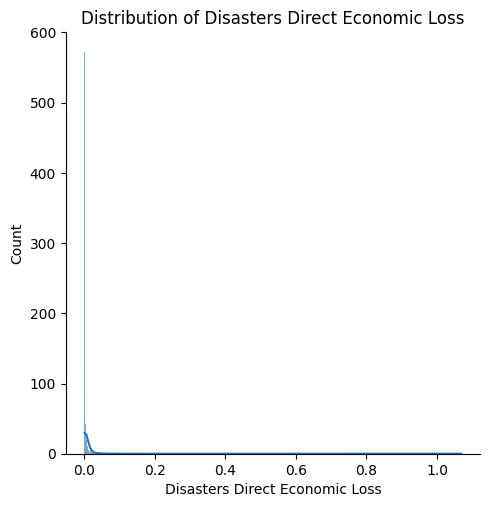

<Figure size 800x400 with 0 Axes>

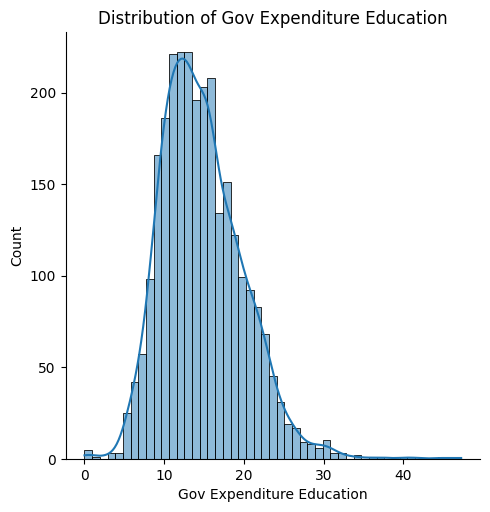

<Figure size 800x400 with 0 Axes>

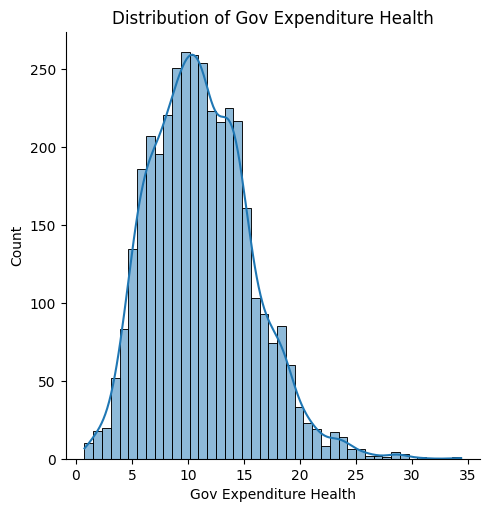

<Figure size 800x400 with 0 Axes>

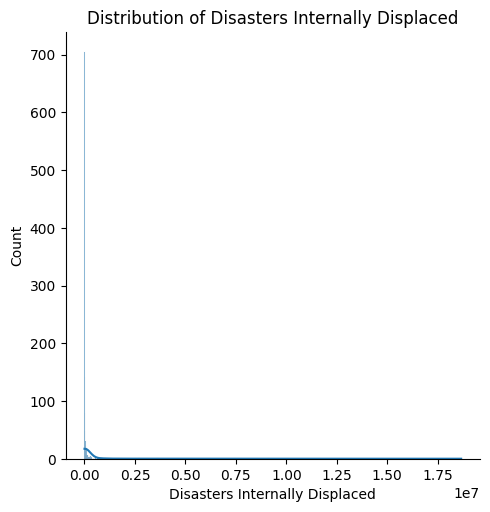

<Figure size 800x400 with 0 Axes>

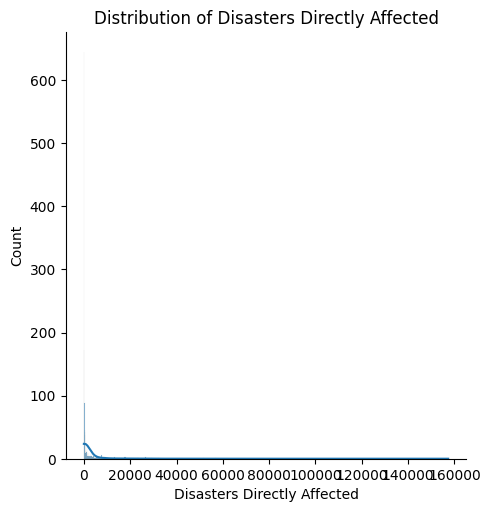

<Figure size 800x400 with 0 Axes>

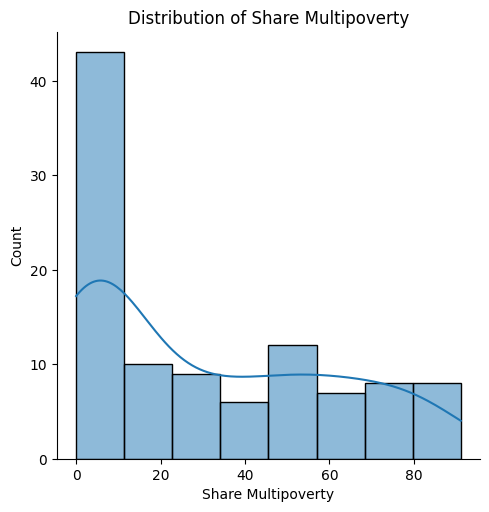

<Figure size 800x400 with 0 Axes>

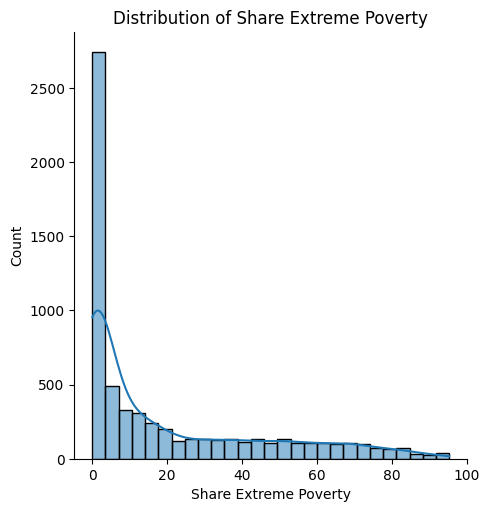

<Figure size 800x400 with 0 Axes>

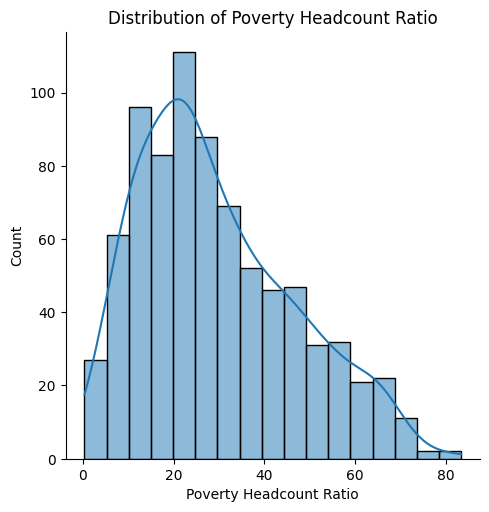


Revisiting 'Share Extreme Poverty' distribution with adjusted parameters...

Original-like distribution plot for Share Extreme Poverty:


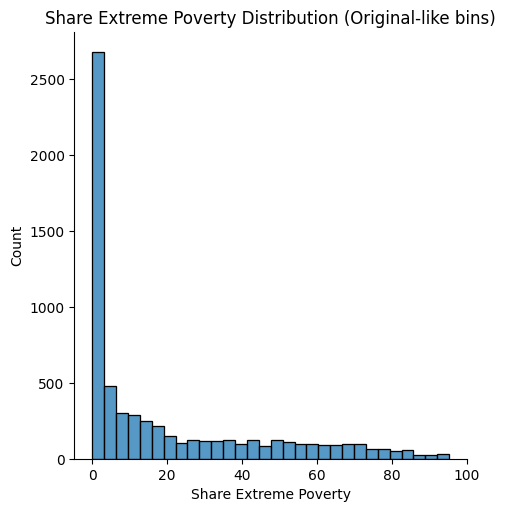


Improved distribution plot for Share Extreme Poverty (more bins, KDE, and element='step'):


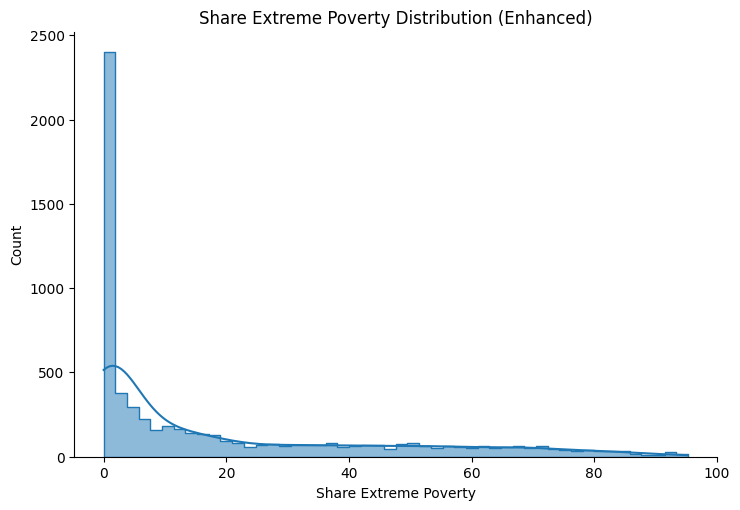


Another enhanced version: using log scale for X-axis if data is highly skewed and concentrated near zero, and adding hue by Continent


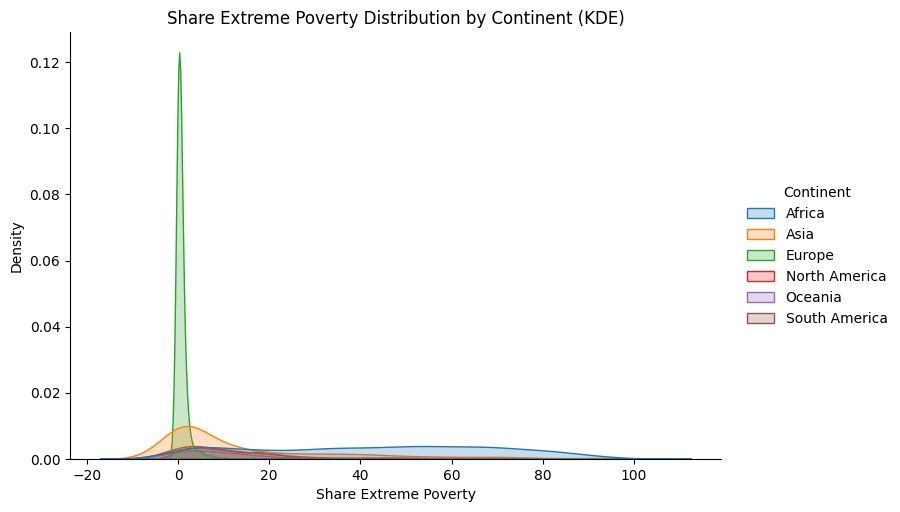

In [28]:
numerical_cols_for_pairplot = [
    "SIP Coverage",
    "Share Extreme Poverty",
    "Gov Expenditure Education",
    "Gov Expenditure Health",
    "Poverty Headcount Ratio"
]

# Create a copy to avoid SettingWithCopyWarning
poverty_data_numerical = poverty_data[numerical_cols_for_pairplot].copy()

print("Generating pairplot for selected numerical features...")
sns.pairplot(data=poverty_data_numerical.dropna())
plt.suptitle('Pairplot of Selected Numerical Features', y=1.02)
plt.show()

# Based on the pairplot (and prior context), two feature pairs to pay more attention to are:
# - SIP Coverage vs Share Extreme Poverty
# - Gov Expenditure Education vs Gov Expenditure Health

print("\nGenerating jointplot for SIP Coverage vs Share Extreme Poverty...")
sns.jointplot(data=poverty_data.dropna(subset=['SIP Coverage', 'Share Extreme Poverty']),
              x="SIP Coverage",
              y="Share Extreme Poverty",
              kind='scatter')
plt.suptitle('Jointplot: SIP Coverage vs Share Extreme Poverty', y=1.02) # Adjust suptitle position
plt.show()

print("\nGenerating jointplot for Gov Expenditure Education vs Gov Expenditure Health...")
sns.jointplot(data=poverty_data.dropna(subset=['Gov Expenditure Education', 'Gov Expenditure Health']),
              x="Gov Expenditure Education",
              y="Gov Expenditure Health",
              kind='hex') # Using 'hex' kind for variety
plt.suptitle('Jointplot: Gov Expenditure Education vs Gov Expenditure Health', y=1.02)
plt.show()

print("\nPlotting distributions of all numerical features...")

numerical_features = poverty_data.select_dtypes(include=['float64']).columns.tolist()

for col in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.displot(data=poverty_data, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

print("\nRevisiting 'Share Extreme Poverty' distribution with adjusted parameters...")
# 'Share Extreme Poverty' often has a right-skewed distribution and potentially outliers.
# We can adjust the bins and add a kernel density estimate for better visualization.

print("\nOriginal-like distribution plot for Share Extreme Poverty:")
sns.displot(data=poverty_data, x="Share Extreme Poverty", bins=30, kde=False)
plt.title('Share Extreme Poverty Distribution (Original-like bins)')
plt.show()

# Improved version: Use more appropriate binning and KDE for smoother representation
print("\nImproved distribution plot for Share Extreme Poverty (more bins, KDE, and element='step'):")
sns.displot(data=poverty_data,
            x="Share Extreme Poverty",
            bins=50, # More bins for finer detail
            kde=True,  # Add Kernel Density Estimate for smoothness
            element="step", # Use step plot for clarity of histogram bars
            height=5, aspect=1.5)
plt.title('Share Extreme Poverty Distribution (Enhanced)')
plt.show()

print("\nAnother enhanced version: using log scale for X-axis if data is highly skewed and concentrated near zero, and adding hue by Continent")

filtered_data = poverty_data.dropna(subset=['Share Extreme Poverty', 'Continent']).copy()


sns.displot(data=filtered_data,
            x="Share Extreme Poverty",
            hue="Continent",
            kind="kde",
            fill=True,
            height=5, aspect=1.5)
plt.title('Share Extreme Poverty Distribution by Continent (KDE)')
plt.show()



Distribution of 'Share Extreme Poverty' without KDE (histogram only):


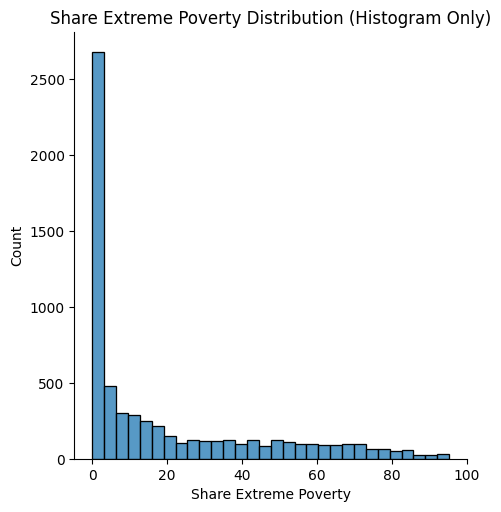


Distribution of 'Share Extreme Poverty' with KDE (histogram + smoothed curve):


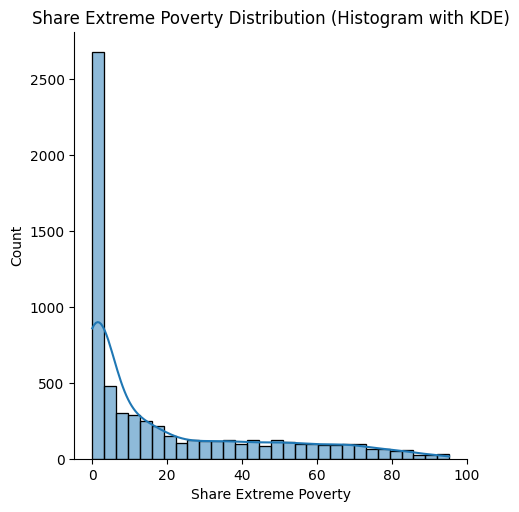


Distribution of 'Share Extreme Poverty' with KDE (KDE only, kind='kde'):


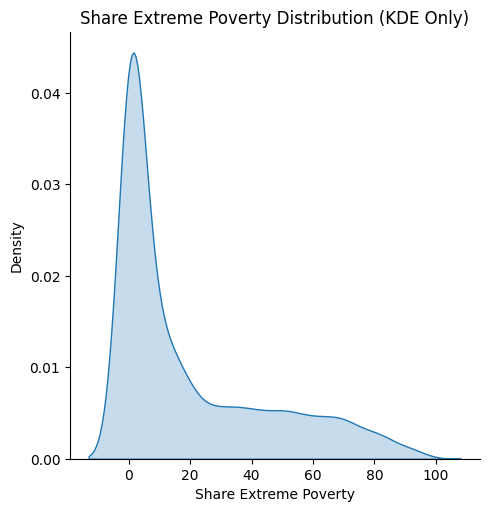

In [29]:
print("\nDistribution of 'Share Extreme Poverty' without KDE (histogram only):")
sns.displot(data=poverty_data, x="Share Extreme Poverty", bins=30, kde=False)
plt.title('Share Extreme Poverty Distribution (Histogram Only)')
plt.show()

print("\nDistribution of 'Share Extreme Poverty' with KDE (histogram + smoothed curve):")
sns.displot(data=poverty_data, x="Share Extreme Poverty", bins=30, kde=True)
plt.title('Share Extreme Poverty Distribution (Histogram with KDE)')
plt.show()

print("\nDistribution of 'Share Extreme Poverty' with KDE (KDE only, kind='kde'):")
sns.displot(data=poverty_data, x="Share Extreme Poverty", kind='kde', fill=True)
plt.title('Share Extreme Poverty Distribution (KDE Only)')
plt.show()


--- Share Extreme Poverty Distribution ---
Linear Scale:


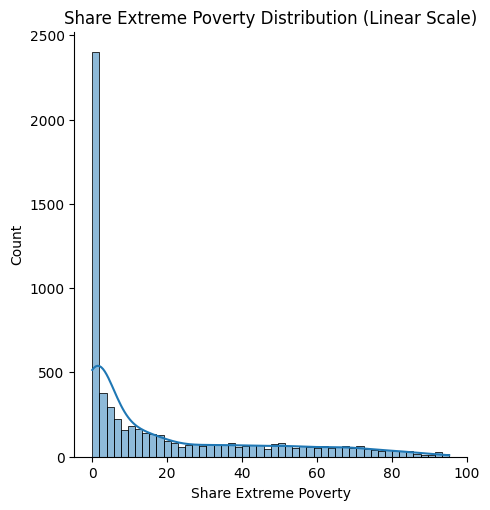

Logarithmic Scale (excluding zeros and NaNs):


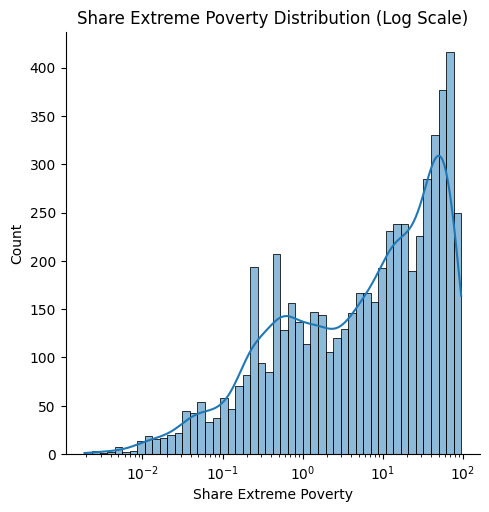


--- Disasters Direct Economic Loss Distribution ---
Linear Scale (excluding NaNs and zeros if any):


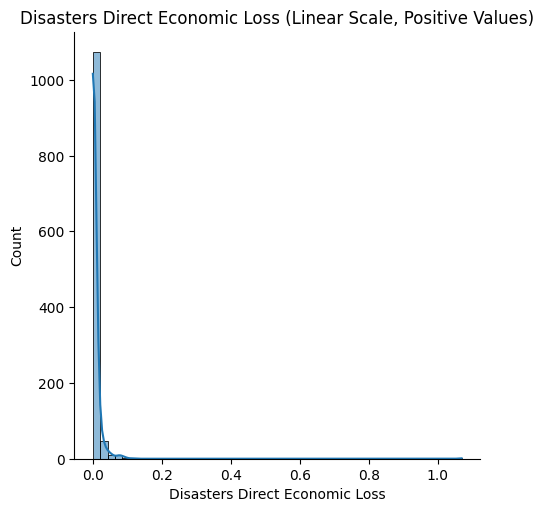

Logarithmic Scale (excluding zeros and NaNs):


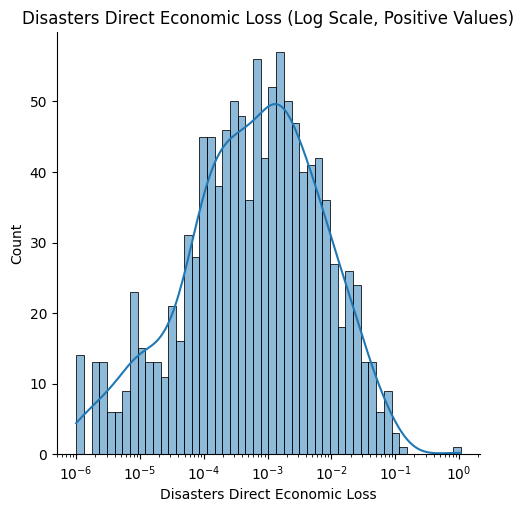

In [30]:
import numpy as np
# Identify plots that need refinement with log_scale
print("\n--- Share Extreme Poverty Distribution ---")
print("Linear Scale:")
sns.displot(data=poverty_data, x="Share Extreme Poverty", bins=50, kde=True)
plt.title('Share Extreme Poverty Distribution (Linear Scale)')
plt.show()

print("Logarithmic Scale (excluding zeros and NaNs):")
# Filter out NaN values and positive values for log transformation
positive_share_extreme_poverty = poverty_data[poverty_data['Share Extreme Poverty'] > 0]['Share Extreme Poverty'].dropna()

if not positive_share_extreme_poverty.empty:
    sns.displot(x=positive_share_extreme_poverty, bins=50, kde=True, log_scale=True)
    plt.title('Share Extreme Poverty Distribution (Log Scale)')
    plt.show()
else:
    print("No positive values to plot on a logarithmic scale for 'Share Extreme Poverty'.")

print("\n--- Disasters Direct Economic Loss Distribution ---")
print("Linear Scale (excluding NaNs and zeros if any):")

disaster_loss_data = poverty_data['Disasters Direct Economic Loss'].dropna()

if not disaster_loss_data.empty:
    # Only plot positive values for meaningful linear histogram, as zeros would dominate
    positive_disaster_loss_data_linear = disaster_loss_data[disaster_loss_data > 0]
    if not positive_disaster_loss_data_linear.empty:
        sns.displot(x=positive_disaster_loss_data_linear, bins=50, kde=True)
        plt.title('Disasters Direct Economic Loss (Linear Scale, Positive Values)')
        plt.show()
    else:
        print("No positive values to plot on a linear scale for 'Disasters Direct Economic Loss'.")
else:
    print("No data available after dropping NaNs for 'Disasters Direct Economic Loss'.")

print("Logarithmic Scale (excluding zeros and NaNs):")
# Filter out NaN values and positive values for log transformation
positive_disaster_loss_data_log = poverty_data[poverty_data['Disasters Direct Economic Loss'] > 0]['Disasters Direct Economic Loss'].dropna()

if not positive_disaster_loss_data_log.empty:
    sns.displot(x=positive_disaster_loss_data_log, bins=50, kde=True, log_scale=True)
    plt.title('Disasters Direct Economic Loss (Log Scale, Positive Values)')
    plt.show()
else:
    print("No positive values to plot on a logarithmic scale for 'Disasters Direct Economic Loss'. This is likely due to many zeros or NaNs in the original data, and log(0) is undefined.")



In [31]:
filtered_poverty_data = poverty_data.dropna(subset=["Gov Expenditure Health", "Gov Expenditure Education", "SIP Coverage", "Continent"]).copy()

fig = px.scatter(data_frame=filtered_poverty_data,
	x="Gov Expenditure Health",
	y="Gov Expenditure Education",
	color="Continent",
	hover_name="Country",
	size="SIP Coverage",
	size_max=40,
	title="""Gov Expenditures & SIP Coverage
	in 2012 per Continent and Country""")
fig.show()